In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
actuals = pd.read_csv('../public/data/actuals_jan.csv')
forecasts = pd.read_csv('../public/data/forecasts_jan.csv')

# Convert to datetime and normalize (round to 30 mins)
actuals['startTime'] = pd.to_datetime(actuals['startTime']).dt.round('30min')
forecasts['startTime'] = pd.to_datetime(forecasts['startTime']).dt.round('30min')
forecasts['publishTime'] = pd.to_datetime(forecasts['publishTime'])

# Calculate the actual Horizon for every forecast row
forecasts['horizon_hours'] = (forecasts['startTime'] - forecasts['publishTime']).dt.total_seconds() / 3600

# Filter for the 0-48h requirement
forecasts = forecasts[(forecasts['horizon_hours'] >= 0) & (forecasts['horizon_hours'] <= 48)]

In [ ]:

latest_f = forecasts.sort_values('publishTime').groupby('startTime').last().reset_index()
merged = pd.merge(actuals, latest_f, on='startTime', suffixes=('_act', '_for'))


merged['abs_error'] = abs(merged['generation_act'] - merged['generation_for'])


metrics = {
    "Mean Absolute Error": merged['abs_error'].mean(),
    "Median Absolute Error": merged['abs_error'].median(),
    "P99 Error (99th Percentile)": merged['abs_error'].quantile(0.99)
}

for k, v in metrics.items():
    print(f"{k}: {v:.2f} MW")

Mean Absolute Error: 1413.50 MW
Median Absolute Error: 873.68 MW
P99 Error (99th Percentile): 7039.89 MW


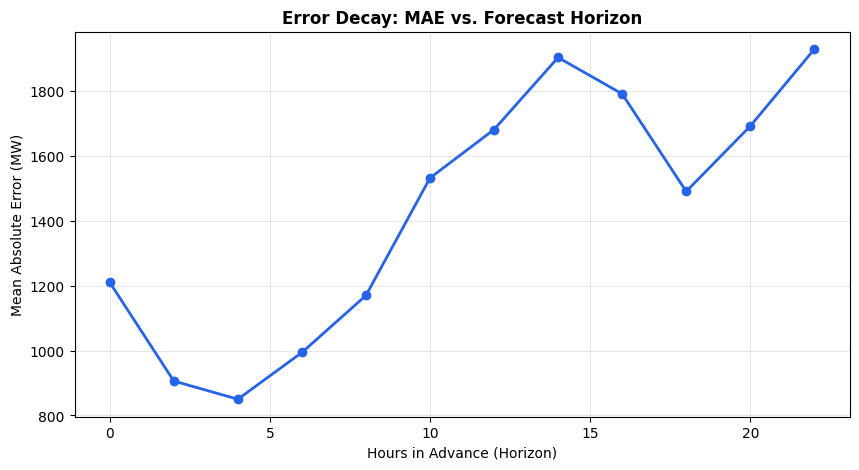

In [ ]:

forecasts['horizon_bin'] = forecasts['horizon_hours'].round()
merged_all = pd.merge(actuals, forecasts, on='startTime', suffixes=('_act', '_for'))
merged_all['abs_error'] = abs(merged_all['generation_act'] - merged_all['generation_for'])

horizon_impact = merged_all.groupby('horizon_bin')['abs_error'].mean()

plt.figure(figsize=(10, 5))
horizon_impact.plot(kind='line', marker='o', color='#2563eb', linewidth=2)
plt.title('Error Decay: MAE vs. Forecast Horizon', fontweight='bold')
plt.xlabel('Hours in Advance (Horizon)')
plt.ylabel('Mean Absolute Error (MW)')
plt.grid(alpha=0.3)
plt.show()

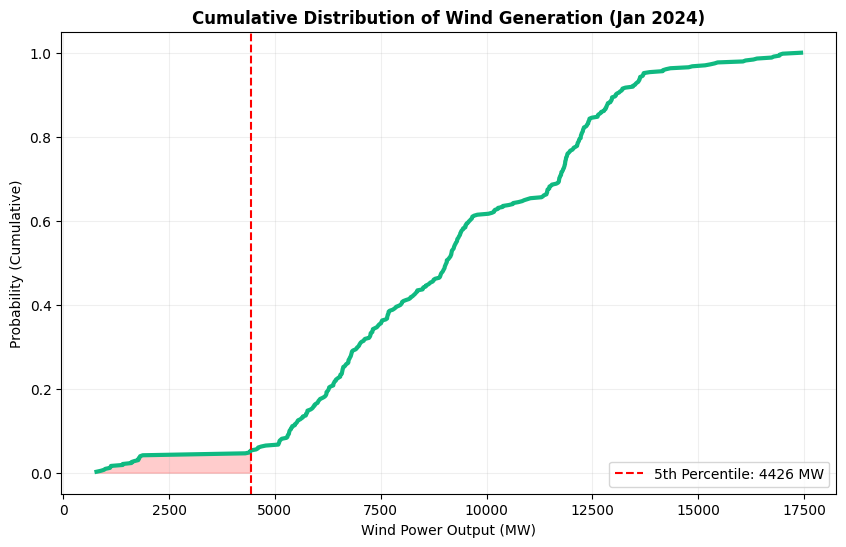

REINT.AI RECOMMENDATION:
We recommend a reliable capacity baseline of 4426.16 MW.
Reasoning: In Jan 2024, wind generation exceeded this value 95% of the time.
Relying on anything higher poses a significant risk to grid stability during low-wind periods.


In [ ]:

sorted_gen = np.sort(actuals['generation'])
y = np.arange(1, len(sorted_gen) + 1) / len(sorted_gen)


reliable_threshold = np.percentile(sorted_gen, 5)

plt.figure(figsize=(10, 6))
plt.plot(sorted_gen, y, color='#10b981', linewidth=3)
plt.axvline(reliable_threshold, color='red', linestyle='--', label=f'5th Percentile: {reliable_threshold:.0f} MW')
plt.fill_between(sorted_gen, y, where=(sorted_gen <= reliable_threshold), color='red', alpha=0.2)

plt.title('Cumulative Distribution of Wind Generation (Jan 2024)', fontweight='bold')
plt.xlabel('Wind Power Output (MW)')
plt.ylabel('Probability (Cumulative)')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

print(f"REINT.AI RECOMMENDATION:")
print(f"We recommend a reliable capacity baseline of {reliable_threshold:.2f} MW.")
print(f"Reasoning: In Jan 2024, wind generation exceeded this value 95% of the time.")
print(f"Relying on anything higher poses a significant risk to grid stability during low-wind periods.")